# <center>**Combination of Data Analysis of CD36 and Listeria  peri nuclei signaling** </center>

## **Import the essential libraries** 

In [1]:
from pathlib import Path
from typing import List, Dict
import pandas as pd
from matplotlib import pyplot as plt
import statistics as st
import statsmodels.api as sm
import numpy as np
import random as rd
import os
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## **Setup output format** 

In [2]:
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 30)

## **Declare the output folder**

In [3]:
result_folder="result4_ex_plate2"
os.makedirs(result_folder, exist_ok=True)
result_path=Path.cwd()/result_folder
print(result_path)

D:\IPPTPAN\Project\Population effect of Macrophase\code_to_git_for_publication\Co_code\result4_ex_plate2


## **Load input data** 

### IF48

In [4]:
# load quantifications
file_pathIF48 = "IF48_listeria.pkl.gz"
quant_dfIF48 = pd.read_pickle(file_pathIF48, compression='gzip')
quant_dfIF48['circularity_normalized'] = quant_dfIF48['circularity'] / quant_dfIF48['nuc_area']**0.2 #Add circularity normalized by area
quant_dfIF48["ExID"]="IF48"
quant_dfIF48.columns
#quant_dfIF48=quant_dfIF48.loc[quant_dfIF48.index.get_level_values("Plate")!=2].copy() # Exclude plate number 2
print(quant_dfIF48.index.get_level_values("Well").unique(),len(quant_dfIF48.index.get_level_values("Well").unique()))


Index(['0202', '0203', '0204', '0302', '0303', '0304', '0402', '0403', '0404',
       '0502', '0503', '0504', '0602', '0603', '0604', '0702', '0703', '0704'],
      dtype='object', name='Well') 18


In [5]:
quant_dfIF48

nuc_area  nuc_area_masked  nuc_eccentricity  \
Plate Well Clone nucleus_id                                                
1     0202 -1    1             2861.0              0.0             0.027   
                 2             3005.5              0.0             0.048   
                 3             3913.0              0.0             0.026   
                 4             4687.0              0.0             0.047   
                 5             2880.5              0.0             0.005   
...                               ...              ...               ...   
      0704 -1    6591          3990.0              0.0             0.118   
                 6592          3792.5              0.0             0.044   
                 6593          7646.0              0.0             0.147   
                 6594          3769.5              0.0             0.188   
                 6595          4292.0              0.0             0.174   

                             nuc_is_toggled  nuc_center_x  nuc_center_y  \
Plate Well Clone nucleus_id                                               
1     0202 -1    1                        0      10711.28      10698.02   
                 2                        0       7909.45      10694.74   
                 3                        0       5076.81      10696.51   
                 4                        0       7799.00      10692.00   
                 5                        0       9766.02      10659.57   
...                                     ...           ...           ...   
      0704 -1    6591                     0       2420.24        146.28   
                 6592                     0       9553.93        133.29   
                 6593                     0       4960.12        130.31   
                 6594                     0       3362.87        101.48   
                 6595                     0       3234.33         48.32   

                             nuc_listeria_intensity_min  \
Plate Well Clone nucleus_id                               
1     0202 -1    1                                    0   
                 2                                    0   
                 3                                    0   
                 4                                    0   
                 5                                    0   
...                                                 ...   
      0704 -1    6591                                 0   
                 6592                                 0   
                 6593                                 0   
                 6594                                 0   
                 6595                                 0   

                             nuc_listeria_intensity_max  \
Plate Well Clone nucleus_id                               
1     0202 -1    1                                    0   
                 2                                    0   
                 3                                    0   
                 4                                    0   
                 5                                    0   
...                                                 ...   
      0704 -1    6591                                 0   
                 6592                                 0   
                 6593                                 2   
                 6594                                 0   
                 6595                                 0   

                             nuc_listeria_intensity_median  \
Plate Well Clone nucleus_id                                  
1     0202 -1    1                                       0   
                 2                                       0   
                 3                                       0   
                 4                                       0   
                 5                                       0   
...                                                    ...   
      0704 -1    6591           

In [6]:
quant_dfIF48.index.get_level_values("Plate").unique()

Index([1], dtype='int64', name='Plate')

## IF50

In [7]:
file_pathIF50 = "IF50_listeria.pkl.gz"
quant_dfIF50 = pd.read_pickle(file_pathIF50, compression='gzip')
quant_dfIF50['circularity_normalized'] = quant_dfIF50['circularity'] / quant_dfIF50['nuc_area']**0.2 #Add circularity normalized by area
quant_dfIF50["ExID"]="IF50"
quant_dfIF50=quant_dfIF50.loc[quant_dfIF50.index.get_level_values("Plate")!=3].copy() # Exclude plate number 3
new_index = quant_dfIF50.index.set_levels(
    quant_dfIF50.index.levels[quant_dfIF50.index.names.index("Plate")] + 1, 
    level="Plate"
)
quant_dfIF50.index = new_index
quant_dfIF50.columns
print(quant_dfIF50.index.get_level_values("Well").unique(),len(quant_dfIF50.index.get_level_values("Well").unique()))

Index(['0202', '0203', '0204', '0302', '0303', '0304', '0402', '0403', '0404',
       '0502', '0503', '0504', '0602', '0603', '0604', '0702', '0703', '0704'],
      dtype='object', name='Well') 18


## IF54

In [8]:
file_pathIF54 = "IF54_listeria.pkl.gz"
quant_dfIF54 = pd.read_pickle(file_pathIF54, compression='gzip')
quant_dfIF54['circularity_normalized'] = quant_dfIF54['circularity'] / quant_dfIF54['nuc_area']**0.2 #Add circularity normalized by area
quant_dfIF54["ExID"]="IF54"
#quant_dfIF54=quant_dfIF54.loc[quant_dfIF54.index.get_level_values("Plate")!=3].copy() # Exclude plate number 3
new_index = quant_dfIF54.index.set_levels(
    quant_dfIF54.index.levels[quant_dfIF50.index.names.index("Plate")] + 2, 
    level="Plate"
)
quant_dfIF54.index = new_index
quant_dfIF54.columns
print(quant_dfIF54.index.get_level_values("Well").unique(),len(quant_dfIF50.index.get_level_values("Well").unique()))

Index(['0202', '0203', '0204', '0302', '0303', '0304', '0402', '0403', '0404',
       '0502', '0503', '0504', '0602', '0603', '0604', '0702', '0703', '0704'],
      dtype='object', name='Well') 18


In [9]:
quant_df=pd.concat([quant_dfIF48,quant_dfIF50,quant_dfIF54])
quant_df = quant_df.sort_index()
quant_df_not_filter=quant_df.copy()

In [10]:
quant_df.query("nucleus_id==3075")[['nuc_eccentricity','nuc_area','solidity','circularity',
                      'longest_hv_stretch','circularity_normalized',"distance_to_corner"]]

nuc_eccentricity  nuc_area  solidity  \
Plate Well Clone nucleus_id                                         
1     0202 -1    3075                   0.210    2449.5  0.983642   
      0203 -1    3075                   0.324    2870.5  0.900763   
      0204 -1    3075                   0.072    5069.0  0.950589   
      0302 -1    3075                   0.037    1817.5  1.000000   
      0303 -1    3075                   0.251    2019.5  0.995172   
...                                       ...       ...       ...   
3     0603 -1    3075                   0.041    2574.5  1.000000   
      0604 -1    3075                   0.056    1732.0  1.000000   
      0702 -1    3075                   0.220    2835.5  0.848013   
      0703 -1    3075                   0.192    1379.5  0.979735   
      0704 -1    3075                   0.116    2457.5  1.000000   

                             circularity  longest_hv_stretch  \
Plate Well Clone nucleus_id                                    
1     0202 -1    3075           0.716151                  14   
      0203 -1    3075           0.559630                  15   
      0204 -1    3075           0.621508                  11   
      0302 -1    3075           0.792916                   8   
      0303 -1    3075           0.694041                   9   
...                                  ...                 ...   
3     0603 -1    3075           0.794019                  12   
      0604 -1    3075           0.792818                  15   
      0702 -1    3075           0.502796                  14   
      0703 -1    3075           0.645442                   9   
      0704 -1    3075           0.784920                  11   

                             circularity_normalized  distance_to_corner  
Plate Well Clone nucleus_id                                              
1     0202 -1    3075                      0.150380                2305  
      0203 -1    3075                      0.113844                1801  
      0204 -1    3075                      0.112840                   0  
      0302 -1    3075                      0.176739                2961  
      0303 -1    3075                      0.151473                8016  
...                                             ...                 ...  
3     0603 -1    3075                      0.165079                1026  
      0604 -1    3075                      0.178428                 717  
      0702 -1    3075                      0.102534                5614  
      0703 -1    3075                      0.152024                2424  
      0704 -1    3075                      0.164712                 492  

[43 rows x 7 columns]

### **Verifing the Data**

In [11]:
quant_df.columns

Index(['nuc_area', 'nuc_area_masked', 'nuc_eccentricity', 'nuc_is_toggled',
       'nuc_center_x', 'nuc_center_y', 'nuc_listeria_intensity_min',
       'nuc_listeria_intensity_max', 'nuc_listeria_intensity_median',
       'nuc_listeria_intensity_quartile1',
       ...
       'per_dna_intensity_h2_mean', 'per_dna_intensity_inertia',
       'per_dna_intensity_sum', 'origin', 'solidity', 'circularity',
       'longest_hv_stretch', 'distance_to_corner', 'circularity_normalized',
       'ExID'],
      dtype='object', length=135)

In [12]:
quant_df.index.get_level_values("Well").unique()

Index(['0202', '0203', '0204', '0302', '0303', '0304', '0402', '0403', '0404',
       '0502', '0503', '0504', '0602', '0603', '0604', '0702', '0703', '0704'],
      dtype='object', name='Well')

In [13]:
quant_df.shape

(425067, 135)

### **Applying Constrains for Data Cleaning**

Area 425067
count    405050.000000
mean       2564.713892
std         967.461594
min        1126.500000
25%        1863.000000
50%        2394.000000
75%        3076.000000
max       10134.000000
Name: nuc_area, dtype: object
Area 405050


<Axes: >

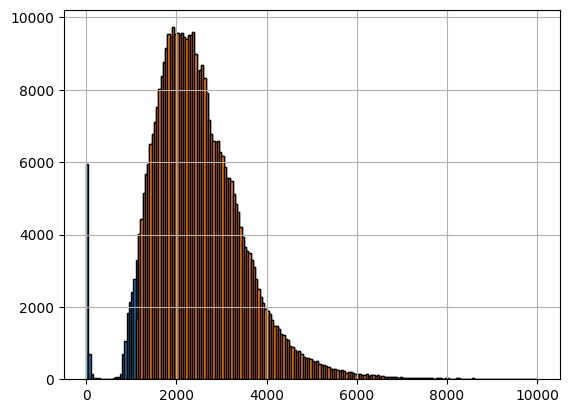

In [14]:
quant_df["nuc_area"].hist(bins=200, range=(0,10000), edgecolor="black", alpha=1.0,)
print("Area",len(quant_df))
# TO_UM2 = 0.598**2 # remove nuclei that are too small or too large
TO_UM2 = 0.149**2 # remove nuclei that are too small or too large
MIN_AREA_UM2, MAX_AREA_UM2= 25, 225
quant_df = quant_df[ (MIN_AREA_UM2 <= quant_df["nuc_area"]*TO_UM2) & (quant_df["nuc_area"]*TO_UM2 <= MAX_AREA_UM2) ]
print(quant_df["nuc_area"].describe().apply(lambda x: f"{x:.6f}")) 
print("Area",len(quant_df))
quant_df["nuc_area"].hist(bins=200, range=(0,10000), edgecolor="black", alpha=1.0,)


ECC 405050
count    405048.000000
mean          0.114673
std           0.084717
min           0.000000
25%           0.053000
50%           0.093000
75%           0.152000
max           0.713000
Name: nuc_eccentricity, dtype: float64
ECC 405048


<Axes: >

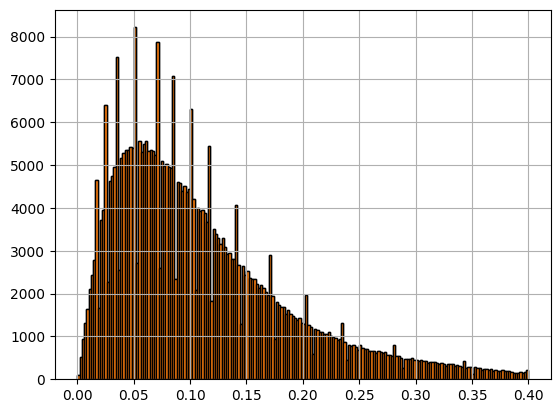

In [15]:
quant_df["nuc_eccentricity"].hist(bins=200, range=(0,0.4), edgecolor="black", alpha=1.0)
print("ECC",len(quant_df))
# ECC=0.3
ECC=0.8 # remove nuclei that are not round - eccentricity > 0.3)
quant_df=quant_df[quant_df["nuc_eccentricity"] <ECC]
print(quant_df["nuc_eccentricity"].describe())
print("ECC",len(quant_df))
quant_df["nuc_eccentricity"].hist(bins=200, range=(0,0.4), edgecolor="black", alpha=1.0)

Round 405048
count    402902.000000
mean          0.147584
std           0.025124
min           0.050003
25%           0.138186
50%           0.154529
75%           0.163845
max           0.194909
Name: circularity_normalized, dtype: float64
Round 402902


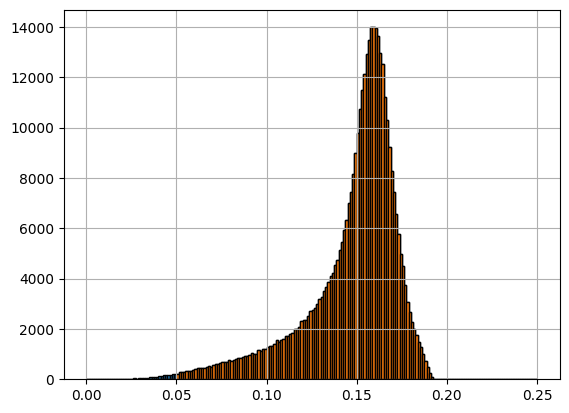

In [16]:
quant_df["circularity_normalized"].hist(bins=200, range=(0,0.25), edgecolor="black", alpha=1.0)
print("Round",len(quant_df))
# CN0=0.125 # remove nuclei that are not circular 
CN0=0.05
quant_df=quant_df[quant_df["circularity_normalized"] > CN0]
print(quant_df["circularity_normalized"].describe())
quant_df["circularity_normalized"].hist(bins=200, range=(0,0.25), edgecolor="black", alpha=1.0)
print("Round",len(quant_df))

Edge 402902
count    402902.000000
mean       4259.824699
std        2802.800128
min           0.000000
25%        2045.000000
50%        4011.000000
75%        6287.000000
max       14373.000000
Name: distance_to_corner, dtype: float64
Edge 402902


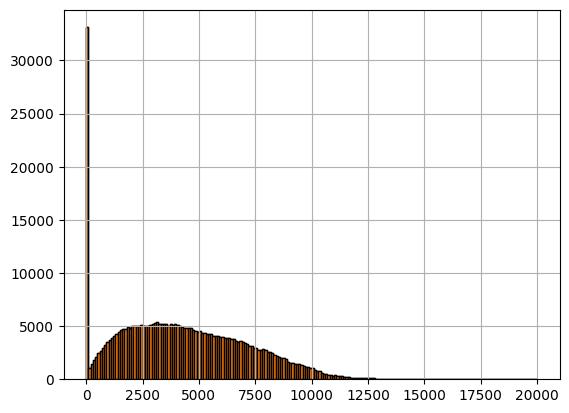

In [17]:
quant_df["distance_to_corner"].hist(bins=200, range=(0,20000), edgecolor="black", alpha=1.0)
print("Edge",len(quant_df))
D0=0 # remove nuclei that are close to the edge (in  pixels) 
quant_df=quant_df[quant_df["distance_to_corner"] >= D0]
print(quant_df["distance_to_corner"].describe())
quant_df["distance_to_corner"].hist(bins=200, range=(0,20000), edgecolor="black", alpha=1.0)
print("Edge",len(quant_df))

In [18]:
# remove nuclei for which there is no perinuclei
a=len(quant_df)
quant_df = quant_df[quant_df['per_area'] != 0]
print('Removed',a-len(quant_df[quant_df['per_area'] != 0]),'nuclei')
print("Total number of nuclei are removed",a)

Removed 99 nuclei
Total number of nuclei are removed 402902


In [19]:
def filter_constrain(quant_df,scale=0.149):
    TO_UM2 = scale**2 # remove nuclei that are too small or too large
    MIN_AREA_UM2, MAX_AREA_UM2= 25*scale**2, 225*scale**2
    quant_df = quant_df[ (MIN_AREA_UM2 <= quant_df["nuc_area"]*TO_UM2) & (quant_df["nuc_area"]*TO_UM2 <= MAX_AREA_UM2) ]
    ECC=0.3 # remove nuclei that are not round - eccentricity > 0.3)
    quant_df=quant_df[quant_df["nuc_eccentricity"] <ECC]
    CN0=0.145 # remove nuclei that are not circular 
    quant_df=quant_df[quant_df["circularity_normalized"] > CN0]
    HV0=12 # remove nuclei that are flat on one side 
    quant_df=quant_df[quant_df["longest_hv_stretch"] <= HV0]
    D0=10 # remove nuclei that are close to the edge (in  pixels) 
    quant_df=quant_df[quant_df["distance_to_corner"] > D0]
    # remove nuclei for which there is no perinuclei
    a=len(quant_df)
    quant_df = quant_df[quant_df['per_area'] != 0]
    print('Removed',a-len(quant_df[quant_df['per_area'] != 0]),'nuclei')
    print("Total number of nuclei are removed",a)
    return quant_df

In [20]:
# quant_df = filter_constrain(quant_df,scale=0.149)

In [21]:
quant_df

nuc_area  nuc_area_masked  nuc_eccentricity  \
Plate Well Clone nucleus_id                                                
1     0202 -1    1             2861.0              0.0             0.027   
                 2             3005.5              0.0             0.048   
                 3             3913.0              0.0             0.026   
                 4             4687.0              0.0             0.047   
                 5             2880.5              0.0             0.005   
...                               ...              ...               ...   
3     0704 -1    8122          4298.5              0.0             0.208   
                 8123          5801.5              0.0             0.136   
                 8124          4211.0              0.0             0.100   
                 8125          4302.0              0.0             0.192   
                 8126          4479.0              0.0             0.151   

                             nuc_is_toggled  nuc_center_x  nuc_center_y  \
Plate Well Clone nucleus_id                                               
1     0202 -1    1                        0      10711.28      10698.02   
                 2                        0       7909.45      10694.74   
                 3                        0       5076.81      10696.51   
                 4                        0       7799.00      10692.00   
                 5                        0       9766.02      10659.57   
...                                     ...           ...           ...   
3     0704 -1    8122                     0       3404.59        268.17   
                 8123                     0       9020.04        261.46   
                 8124                     0       6744.44        127.79   
                 8125                     0       7943.12        130.93   
                 8126                     0        192.32         76.20   

                             nuc_listeria_intensity_min  \
Plate Well Clone nucleus_id                               
1     0202 -1    1                                    0   
                 2                                    0   
                 3                                    0   
                 4                                    0   
                 5                                    0   
...                                                 ...   
3     0704 -1    8122                                 0   
                 8123                                 0   
                 8124                                 0   
                 8125                                 0   
                 8126                                 0   

                             nuc_listeria_intensity_max  \
Plate Well Clone nucleus_id                               
1     0202 -1    1                                    0   
                 2                                    0   
                 3                                    0   
                 4                                    0   
                 5                                    0   
...                                                 ...   
3     0704 -1    8122                                 0   
                 8123                                 0   
                 8124                                 0   
                 8125                                 0   
                 8126                                60   

                             nuc_listeria_intensity_median  \
Plate Well Clone nucleus_id                                  
1     0202 -1    1                                       0   
                 2                                       0   
                 3                                       0   
                 4                                       0   
                 5                                       0   
...                                                    ...   
3     0704 -1    8122           

### **Manually Enumerate Different Treatment Conditions In The Main DataFrame**

In [22]:
# Define a function to assign the 'Lipid A' condition based on the well
def assign_SSO_condition(well):
    if well.startswith('02') or well.startswith('03') or well.startswith('04') or well.startswith('06') :
        return 'Mock'
    elif well.startswith('05') or well.startswith('07'):
        return '200 uM'
    else:
        return 'Unknown'  # Optional, for wells not starting with '0' or '03'
def assign_Listeria_condition(well):
    if well.startswith('02') or well.startswith('04') or well.startswith('05') :
        return 'Mock'
    elif well.startswith('03') or well.startswith('06') or well.startswith('07'):
        return 'Lm-GFP'
    else:
        return 'Unknown'  # Optional, for wells not starting with '0' or '03'

def assign_MOI_condition(well):
    if well.startswith('02') or well.startswith('04') or well.startswith('05') :
        return 0
    elif well.startswith('03') or well.startswith('06') or well.startswith('07'):
        return 5
    else:
        return 'Unknown'  # Optional, for wells not starting with '0' or '03'
def assign_Inf_Time_condition(well):
    return '24h'
        
def assign_cells_well_condition(well):
    if well.startswith('02') or well.startswith('03'):
        return 10000
    elif well.startswith('04') or well.startswith('05') or well.startswith('06') or well.startswith('07') :
         return 50000
    else:
         return 'Unknown'  # Optional, for wells not starting with '0' or '03'

# def assign_staining_condition(well,ExID):
#     if ExID=="IF22" and (well.startswith('0103') or well.startswith('0203')):
#             return 'No'
#     elif ExID=="IF24" and (well.startswith('0102') or well.startswith('0202')):
#            return 'No'
#     else:
#            return 'Yes'

# Add columns for new conditions
#clones_df = clones_df.reset_index()
quant_df = quant_df.copy()  # Ensure we work with a copy

quant_df.loc[:, 'SSO'] = [

    
    assign_SSO_condition(well)
    for well in quant_df.index.get_level_values('Well').astype(str)
]
quant_df.loc[:, 'Listeria'] = [
    assign_Listeria_condition(well)
    for well in quant_df.index.get_level_values('Well').astype(str)
]

quant_df.loc[:, 'MOI'] = [
    assign_MOI_condition(well)
    for well in quant_df.index.get_level_values('Well').astype(str)
]

quant_df.loc[:, 'Cells_well'] = [
    assign_cells_well_condition(well)
    for well in quant_df.index.get_level_values('Well').astype(str)
]

quant_df.loc[:, 'Inf_Time'] = [
    assign_Inf_Time_condition(well)
    for well in quant_df.index.get_level_values('Well').astype(str)
]

# quant_df["Staining"] = [
#     assign_staining_condition(str(well), exid)
#     for well, exid in zip(
#         quant_df.index.get_level_values("Well").astype(str),
#         quant_df["ExID"].astype(str)
#     )
# ]


quant_df

nuc_area  nuc_area_masked  nuc_eccentricity  \
Plate Well Clone nucleus_id                                                
1     0202 -1    1             2861.0              0.0             0.027   
                 2             3005.5              0.0             0.048   
                 3             3913.0              0.0             0.026   
                 4             4687.0              0.0             0.047   
                 5             2880.5              0.0             0.005   
...                               ...              ...               ...   
3     0704 -1    8122          4298.5              0.0             0.208   
                 8123          5801.5              0.0             0.136   
                 8124          4211.0              0.0             0.100   
                 8125          4302.0              0.0             0.192   
                 8126          4479.0              0.0             0.151   

                             nuc_is_toggled  nuc_center_x  nuc_center_y  \
Plate Well Clone nucleus_id                                               
1     0202 -1    1                        0      10711.28      10698.02   
                 2                        0       7909.45      10694.74   
                 3                        0       5076.81      10696.51   
                 4                        0       7799.00      10692.00   
                 5                        0       9766.02      10659.57   
...                                     ...           ...           ...   
3     0704 -1    8122                     0       3404.59        268.17   
                 8123                     0       9020.04        261.46   
                 8124                     0       6744.44        127.79   
                 8125                     0       7943.12        130.93   
                 8126                     0        192.32         76.20   

                             nuc_listeria_intensity_min  \
Plate Well Clone nucleus_id                               
1     0202 -1    1                                    0   
                 2                                    0   
                 3                                    0   
                 4                                    0   
                 5                                    0   
...                                                 ...   
3     0704 -1    8122                                 0   
                 8123                                 0   
                 8124                                 0   
                 8125                                 0   
                 8126                                 0   

                             nuc_listeria_intensity_max  \
Plate Well Clone nucleus_id                               
1     0202 -1    1                                    0   
                 2                                    0   
                 3                                    0   
                 4                                    0   
                 5                                    0   
...                                                 ...   
3     0704 -1    8122                                 0   
                 8123                                 0   
                 8124                                 0   
                 8125                                 0   
                 8126                                60   

                             nuc_listeria_intensity_median  \
Plate Well Clone nucleus_id                                  
1     0202 -1    1                                       0   
                 2                                       0   
                 3                                       0   
                 4                                       0   
                 5                                       0   
...                                                    ...   
3     0704 -1    8122           

## **Create a clean Data File**

In [23]:
quant_df.to_pickle('cd36_Listeria_clean.pkl')

In [24]:
combined_df =quant_df

## Create combine per + nuc columns

In [25]:
combined_df["nuc_per_listeria_intensity_80_mean"]=combined_df["nuc_listeria_intensity_80_mean"]+combined_df["per_listeria_intensity_80_mean"]

In [26]:
combined_df["nuc_per_cd36_intensity_80_mean"]=combined_df["nuc_cd36_intensity_80_mean"]+combined_df["per_cd36_intensity_80_mean"]

<!-- # Sort data into clones and daughter cells -->

## **Display overview of clean data**

In [27]:
def experiment_plot(combined_df):
    combined_df_exid=combined_df
    plate_clones_df = combined_df_exid.loc[3,:,:,:]
    plate_clones_well_ids = plate_clones_df.index.get_level_values('Well').unique().sort_values()
    plate_clones_well_ids
    # show an overview of clusters
    NCOLS = 5  # Columns from 3 to 10
    NROWS = 8  # Rows from 2 to 8
    
    fig_mosaic = [[f"{r + 0:02d}{c + 0:02d}" for c in range(2,NCOLS)] for r in range(2,NROWS)]
    fig_opts = dict(sharex=True, sharey=True, figsize=(NCOLS*1.5, NROWS*1.5))
    scatter_opts = dict(s=0.3, alpha=0.4, edgecolors='none')
    annot_opts = dict(xy=(0.5, 0.91), xycoords='axes fraction', ha='center', alpha=0.5)
    sides = ('top', 'right', 'left', 'bottom')
    unique_plates = combined_df_exid.index.get_level_values("Plate").unique()
    print(unique_plates)
    for plate in unique_plates:
        plate_clones_df = combined_df_exid.loc[plate, :, :, :]
        plate_clones_well_ids = plate_clones_df.index.get_level_values('Well').unique().sort_values()
        
        fig, axes = plt.subplot_mosaic(fig_mosaic, **fig_opts)
        
        for _, ax in axes.items():
            ax.set_axis_off()
        
        for well in plate_clones_well_ids:
            ax.set_aspect('equal', adjustable='box')
            ax = axes[well]
            ax.set_axis_on()
            for s in sides: ax.spines[s].set_linewidth(0.25)
            ax.set_xticks([]);  ax.set_yticks([])
            ax.set_xlabel('');  ax.set_ylabel('')
            ax.annotate(text=f"{well}", **annot_opts)
    
            well_data = plate_clones_df.loc[well, :, :]
            clones_well_data    = well_data.loc[ well_data.index.get_level_values('Clone') >= 0, :]
            nonclones_well_data = well_data.loc[ well_data.index.get_level_values('Clone') <  0, :]
            
            x, y = nonclones_well_data[['nuc_center_x', 'nuc_center_y']].values.T
            ax.scatter(x, -y, c='gray', **scatter_opts)
            
            x, y = clones_well_data[['nuc_center_x', 'nuc_center_y']].values.T
            c = clones_well_data.index.get_level_values('Clone')
            ax.scatter(x, -y, c=c, cmap='gist_rainbow', **scatter_opts)
    
        fig.suptitle(f"Plate {plate}: Overview of Clusters")
        
        # Instead of fig.tight_layout():
        #fig.tight_layout(h_pad=-0.15, w_pad=-0.1);
        fig.subplots_adjust(wspace=0, hspace=0.02, left=0.01, right=0.78, top=0.95, bottom=0.01)
        #fig.savefig(f"plate_overview--expt--plate_{plate}.png", dpi=600);

Index([1, 2, 3], dtype='int64', name='Plate')


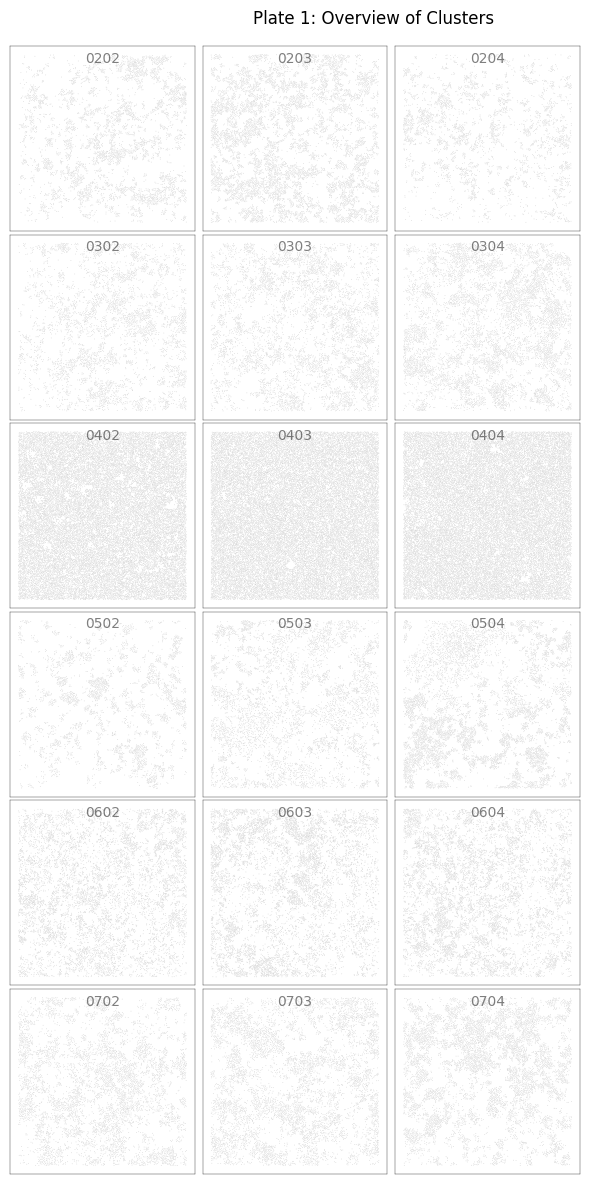

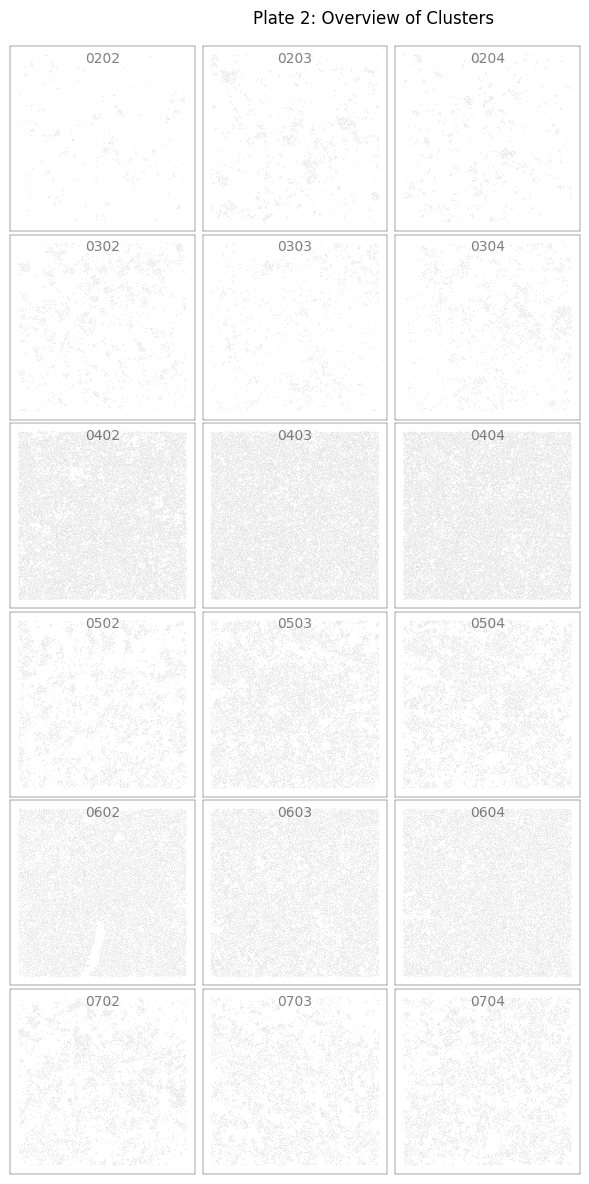

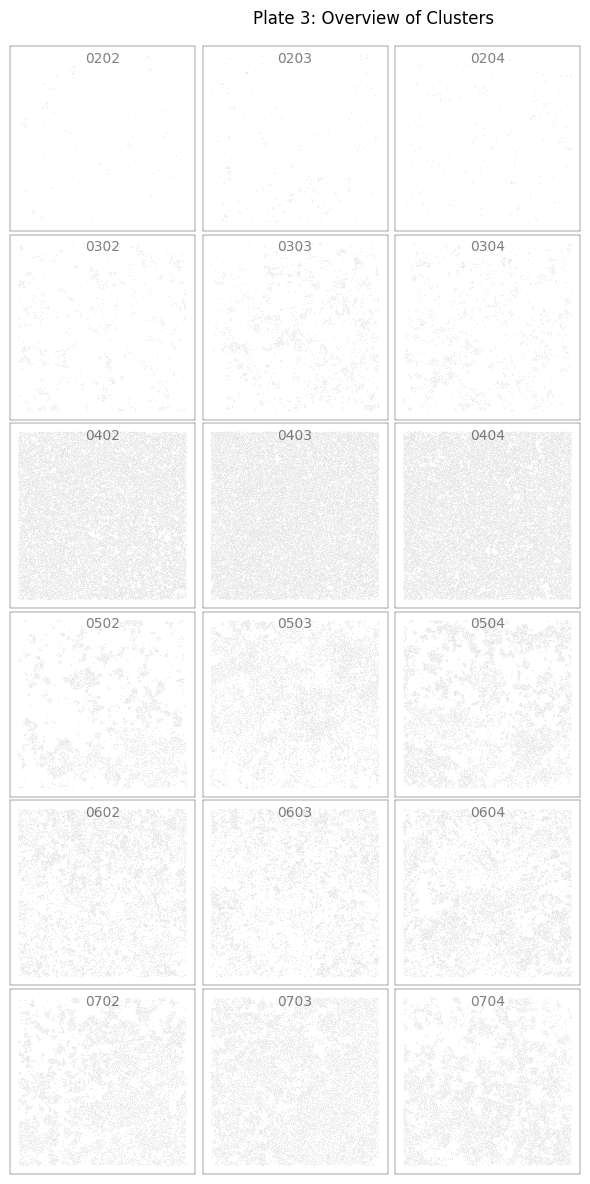

In [28]:
experiment_plot(combined_df)

<!-- - No evidence for stimuli-induced tnfr2 activation
- Plate 2 10000 controls are missing -->

### Help functions

In [29]:
import re
import ast

def parse_query_to_dict(query: str) -> dict:
    out = {}
    # split by "&"
    parts = re.split(r'\s*&\s*', query)
    for part in parts:
        # split by "=="
        key, value = re.split(r'\s*==\s*', part, maxsplit=1)
        key = key.strip()
        value = value.strip()

        # remove surrounding quotes if present
        if (value.startswith('"') and value.endswith('"')) or \
           (value.startswith("'") and value.endswith("'")):
            value = value[1:-1]
        else:
            # try to interpret numbers, booleans, etc.
            try:
                value = ast.literal_eval(value)
            except Exception:
                pass  # leave as string if it fails

        out[key] = value
    return out



In [30]:
locals_dict ={}

In [31]:
def signal_distribution(combined_df,query_cond='Listeria=="Mock" & SSO=="Mock"',locals_dict={"exid": 0,"den": 0}, Detail=False):
    import re
    def extract_equals_pairs(q: str):
    # returns dict of {column: value} for simple == conditions
       return dict(re.findall(r'\b([A-Za-z_]\w*)\s*==\s*["\']([^"\']+)["\']', q))
    labelname = extract_equals_pairs(query_cond)    
    # from scipy.stats import pearsonr  # optional, if you want p-values
    
    # 1) Filter once and keep paired values
    df_pair = combined_df.query(query_cond)[
        ["nuc_per_listeria_intensity_80_mean", "nuc_per_cd36_intensity_80_mean"]
    ].dropna()
    
    x = df_pair["nuc_per_listeria_intensity_80_mean"].to_numpy()
    y = df_pair["nuc_per_cd36_intensity_80_mean"].to_numpy()
    
    # 2) Make side-by-side figure
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    
    # --- LEFT: your histograms (unchanged) ---
    axes[0].hist(x, bins=30, range=(0,255), edgecolor="black", alpha=0.5, label=f"Listeria {labelname.get("Listeria")}, SSO {labelname.get("SSO")}", log=True)
    axes[0].hist(y, bins=30, range=(0,255), edgecolor="black", alpha=0.5, label= "Cd36", log=True)
    axes[0].set_xlabel("Intensity")
    axes[0].set_ylabel("Log(Frequency)")
    axes[0].set_title("Listeria vs CD36 Intensity Signal")
    axes[0].legend()
    
    # --- RIGHT: correlation scatter + trend line ---
    axes[1].scatter(x, y, s=12, alpha=0.6)
    axes[1].set_xlabel("Listeria intensity ")
    axes[1].set_ylabel("CD36 intensity ")
    axes[1].set_title("Correlation: Listeria vs CD36")
    
    # Pearson r (without SciPy)
    r = np.corrcoef(x, y)[0, 1]
    
    # Optional: with SciPy for p-value
    # r, p = pearsonr(x, y)
    
    # Add simple linear fit
    m, b = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 200)
    axes[1].plot(xx, m*xx + b, linewidth=2)
    
    # Annotate correlation
    axes[1].text(0.05, 0.95, f"Pearson r = {r:.3f}", transform=axes[1].transAxes,
                 va="top", ha="left")
    if Detail:
        fig.suptitle(f"ExID {locals_dict["exid"]}, Number of Cells {locals_dict["den"]}", fontsize=14, y=1.1)
    
    plt.show()

            

In [32]:
import numpy as np, pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

#### Spatial autocorrelation (Moran’s I and Bivariate Moran’s I), 
Use spatial statistics to formally test whether intensities are spatially clustered and whether green co-varies with red spatially.  
**Interpretation**:  
Moran’s I > 0 (p<0.05): the signal clusters spatially (neighbors similar).  
Bivariate Moran’s I > 0: areas with high green are surrounded by high red → spatial co-expression.

In [33]:
def spatial_correlation(combined_df,query_cond,plotsignal=False,plotmoran=False):
    import numpy as np
    df=combined_df.query(query_cond)
    if plotsignal:
        signal_distribution(df,query_cond)
    #########################################################
    df = df.dropna(subset=['nuc_center_x','nuc_center_y','nuc_per_listeria_intensity_80_mean','nuc_per_cd36_intensity_80_mean']).copy()
    # optional: log-transform to reduce skew
    # for c in ['nuc_listeria_intensity_80_mean','nuc_cd36_intensity_80_mean']:
    #     df[c] = np.log1p(df[c])  # optional

    # optional: z-score normalize
    df['nuc_per_listeria_intensity_80_mean_z'] = (df['nuc_per_listeria_intensity_80_mean'] - df['nuc_per_listeria_intensity_80_mean'].mean()) / df['nuc_per_listeria_intensity_80_mean'].std()
    df['nuc_per_cd36_intensity_80_mean_z']   = (df['nuc_per_cd36_intensity_80_mean']   - df['nuc_per_cd36_intensity_80_mean'].mean()) / df['nuc_per_cd36_intensity_80_mean'].std()

    #########################################################
    # k-Nearest-Neighbor (kNN) local correlation
    from sklearn.neighbors import NearestNeighbors
    k = 50  # number of neighbors
    nbrs = NearestNeighbors(n_neighbors=k).fit(df[['nuc_center_x','nuc_center_y']])
    indices = nbrs.kneighbors(return_distance=False)
    df['local_corr'] = [df.iloc[idx]['nuc_per_listeria_intensity_80_mean'].corr(df.iloc[idx]['nuc_per_cd36_intensity_80_mean']) for idx in indices]
    #####################################################
    import numpy as np
    import matplotlib.pyplot as plt
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
    
    # ==== 1) Local correlation map (left) ====
    sc0 = axes[0].scatter(
    df['nuc_center_x'],
    df['nuc_center_y'],
    c=df['local_corr'],
    cmap='coolwarm',
    s=15
    )
    axes[0].set_title('nuc-per-nucleus local correlation field')
    axes[0].set_xlabel('nuc_center_x')
    axes[0].set_ylabel('nuc_center_y')
    axes[0].invert_yaxis()
    axes[0].set_aspect('equal', 'box')
    
    # --- attach a perfectly aligned colorbar ---
    divider = make_axes_locatable(axes[0])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cb = plt.colorbar(sc0, cax=cax)
    cb.set_label('Local correlation (r)')
    
    # ==== 2) Combined red/green RGB map (right) ====
    g = df['nuc_per_listeria_intensity_80_mean'].to_numpy().astype(float)
    r = df['nuc_per_cd36_intensity_80_mean'].to_numpy().astype(float)
    
    g_norm = (g - g.min()) / (g.max() - g.min() + 1e-9)
    r_norm = (r - r.min()) / (r.max() - r.min() + 1e-9)
    colors = np.stack([r_norm, g_norm, np.zeros_like(r_norm)], axis=1)
    
    axes[1].scatter(
    df['nuc_center_x'],
    df['nuc_center_y'],
    c=colors,
    s=15
    )
    axes[1].set_title('Combined map – red & green')
    axes[1].set_xlabel('nuc_center_x')
    axes[1].set_ylabel('nuc_center_y')
    axes[1].invert_yaxis()
    axes[1].set_aspect('equal', 'box')
    axes[1].invert_yaxis() 
    plt.tight_layout()
    fig.suptitle(query_cond,fontsize=14,y=1.03)
    plt.show()
    #############################################
    import libpysal
    from esda.moran import Moran, Moran_BV
    from splot.esda import moran_scatterplot
    coords = df[['nuc_center_x','nuc_center_y']].values
    w = libpysal.weights.KNN.from_array(coords, k=8)
    w.transform = 'r'
    I_green = Moran(df['nuc_per_listeria_intensity_80_mean'], w)
    I_red   = Moran(df['nuc_per_cd36_intensity_80_mean'], w)
    I_bivar = Moran_BV(df['nuc_per_listeria_intensity_80_mean'], df['nuc_per_cd36_intensity_80_mean'], w)
    print("Moran's I (Listeria):", I_green.I, "p=", I_green.p_sim)
    print("Moran's I (Cd36):", I_red.I, "p=", I_red.p_sim)
    print("Bivariate Moran's I:", I_bivar.I, "p=", I_bivar.p_sim)
    #############################################
    if plotmoran:
            # --- plots in one row ---
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        # 1) Moran I – Listeria (green)
        moran_scatterplot(I_green, ax=axes[0])
        axes[0].set_title("Moran Scatterplot – Listeria")
        
        # 2) Moran I – Cd36 (red)
        moran_scatterplot(I_red, ax=axes[1])
        axes[1].set_title("Moran Scatterplot – Cd36")
        
        # 3) Bivariate Moran – Listeria vs Cd36
        moran_scatterplot(I_bivar, ax=axes[2])
        axes[2].set_title("Bivariate Moran – Listeria vs Cd36")
        plt.tight_layout()
        plt.show()
        

In [34]:
wells=combined_df.index.get_level_values('Well').unique()
plates=combined_df.index.get_level_values('Plate').unique()
SSO=combined_df["SSO"].unique()
Listeria=combined_df["Listeria"].unique()
query_cond_set = [
    f'Listeria == "{lis}" & SSO == "{so}" & Plate == {pl} & Well == "{we}"'
    for lis in Listeria
    for so in SSO
    for pl in plates
    for we in combined_df.query("Listeria == @lis & SSO == @so ").index.get_level_values("Well").unique() if lis!="Mock"
]

## For Manuscript Plot

In [35]:
query_cond_set_10K = [
    f'Listeria == "{lis}" & SSO == "{so}" & Plate == {pl} & Well == "{we}"'
    for lis in Listeria
    for so in SSO
    for pl in plates
    for we in combined_df.query("Listeria == @lis & SSO == @so & Cells_well==10000").index.get_level_values("Well").unique() if lis!="Mock"
]


In [36]:
query_cond_set_10K

['Listeria == "Lm-GFP" & SSO == "Mock" & Plate == 1 & Well == "0302"',
 'Listeria == "Lm-GFP" & SSO == "Mock" & Plate == 1 & Well == "0303"',
 'Listeria == "Lm-GFP" & SSO == "Mock" & Plate == 1 & Well == "0304"',
 'Listeria == "Lm-GFP" & SSO == "Mock" & Plate == 2 & Well == "0302"',
 'Listeria == "Lm-GFP" & SSO == "Mock" & Plate == 2 & Well == "0303"',
 'Listeria == "Lm-GFP" & SSO == "Mock" & Plate == 2 & Well == "0304"',
 'Listeria == "Lm-GFP" & SSO == "Mock" & Plate == 3 & Well == "0302"',
 'Listeria == "Lm-GFP" & SSO == "Mock" & Plate == 3 & Well == "0303"',
 'Listeria == "Lm-GFP" & SSO == "Mock" & Plate == 3 & Well == "0304"']

In [37]:
query_cond_set_50K_noSSO=[
    f'Listeria == "{lis}" & SSO == "{so}" & Plate == {pl} & Well == "{we}"'
    for lis in Listeria
    for so in ['Mock']
    for pl in plates
    for we in combined_df.query("Listeria == @lis & SSO == @so & Cells_well==50000").index.get_level_values("Well").unique() if lis!="Mock"
]


In [38]:
query_cond_set_50K_noSSO

['Listeria == "Lm-GFP" & SSO == "Mock" & Plate == 1 & Well == "0602"',
 'Listeria == "Lm-GFP" & SSO == "Mock" & Plate == 1 & Well == "0603"',
 'Listeria == "Lm-GFP" & SSO == "Mock" & Plate == 1 & Well == "0604"',
 'Listeria == "Lm-GFP" & SSO == "Mock" & Plate == 2 & Well == "0602"',
 'Listeria == "Lm-GFP" & SSO == "Mock" & Plate == 2 & Well == "0603"',
 'Listeria == "Lm-GFP" & SSO == "Mock" & Plate == 2 & Well == "0604"',
 'Listeria == "Lm-GFP" & SSO == "Mock" & Plate == 3 & Well == "0602"',
 'Listeria == "Lm-GFP" & SSO == "Mock" & Plate == 3 & Well == "0603"',
 'Listeria == "Lm-GFP" & SSO == "Mock" & Plate == 3 & Well == "0604"']

In [39]:
query_cond_set_50K_SSO=[
    f'Listeria == "{lis}" & SSO == "{so}" & Plate == {pl} & Well == "{we}"'
    for lis in Listeria
    for so in ['200 uM']
    for pl in plates
    for we in combined_df.query("Listeria == @lis & SSO == @so & Cells_well==50000").index.get_level_values("Well").unique() if lis!="Mock"
]

In [40]:
query_cond_set_50K_SSO

['Listeria == "Lm-GFP" & SSO == "200 uM" & Plate == 1 & Well == "0702"',
 'Listeria == "Lm-GFP" & SSO == "200 uM" & Plate == 1 & Well == "0703"',
 'Listeria == "Lm-GFP" & SSO == "200 uM" & Plate == 1 & Well == "0704"',
 'Listeria == "Lm-GFP" & SSO == "200 uM" & Plate == 2 & Well == "0702"',
 'Listeria == "Lm-GFP" & SSO == "200 uM" & Plate == 2 & Well == "0703"',
 'Listeria == "Lm-GFP" & SSO == "200 uM" & Plate == 2 & Well == "0704"',
 'Listeria == "Lm-GFP" & SSO == "200 uM" & Plate == 3 & Well == "0702"',
 'Listeria == "Lm-GFP" & SSO == "200 uM" & Plate == 3 & Well == "0703"',
 'Listeria == "Lm-GFP" & SSO == "200 uM" & Plate == 3 & Well == "0704"']

A **bivariate Moran’s I** quantifies how *strongly one variable* (e.g., Listeria) at location *i* is correlated with *another variable* (e.g., Cd36) **in nearby locations** (*neighbors j*).

$$
-1 \leq I \leq 1
$$
| Range           | Interpretation                                            |
| --------------- | --------------------------------------------------------- |
| **> +0.6**      | Very strong spatial co-clustering                         |
| **+0.3 – +0.6** | Moderate spatial co-clustering                            |
| **+0.1 – +0.3** | Weak but positive spatial association                     |
| **0**           | Random spatial relationship                               |
| **< 0**         | Spatial dissimilarity (e.g., high Listeria near low Cd36) |



## Running for all wells

In [41]:
def spatial_correlation_background_Bivariate(combined_df, query_cond, plotsignal=False, plotmoran=False):
    import numpy as np
    import matplotlib.pyplot as plt
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    from sklearn.neighbors import NearestNeighbors
    import libpysal
    from esda.moran import Moran, Moran_BV, Moran_Local_BV
    from splot.esda import moran_scatterplot

    # subset by query
    df = combined_df.query(query_cond)
    if plotsignal:
        signal_distribution(df, query_cond)

    #########################################################
    # clean & standardize
    df = df.dropna(
        subset=[
            'nuc_center_x',
            'nuc_center_y',
            'nuc_per_listeria_intensity_80_mean',
            'nuc_per_cd36_intensity_80_mean'
        ]
    ).copy()
    
    # k-Nearest-Neighbor (kNN) local correlation (Listeria vs Cd36)
    k = 50  # number of neighbors
    nbrs = NearestNeighbors(n_neighbors=k).fit(df[['nuc_center_x', 'nuc_center_y']])
    indices = nbrs.kneighbors(return_distance=False)
    df['local_corr'] = [
        df.iloc[idx]['nuc_per_listeria_intensity_80_mean'].corr(
            df.iloc[idx]['nuc_per_cd36_intensity_80_mean']
        )
        for idx in indices
    ]

    #########################################################
    # Spatial weights for Moran / local bivariate Moran
    coords = df[['nuc_center_x', 'nuc_center_y']].values
    w = libpysal.weights.KNN.from_array(coords, k=8)
    w.transform = 'r'

    I_green = Moran(df['nuc_per_listeria_intensity_80_mean'].values, w)
    I_red   = Moran(df['nuc_per_cd36_intensity_80_mean'].values,    w)
    I_bivar = Moran_BV(
        df['nuc_per_listeria_intensity_80_mean'].values,
        df['nuc_per_cd36_intensity_80_mean'].values,
        w
    )

    # Local bivariate Moran I (per nucleus): Listeria vs neighbors' Cd36
    lisa_bv = Moran_Local_BV(
        df['nuc_per_listeria_intensity_80_mean'].values,
        df['nuc_per_cd36_intensity_80_mean'].values,
        w
    )
    df['local_bivar_moran'] = lisa_bv.Is  # local bivariate Moran statistic

    #########################################################
    # plots: local_corr + local bivariate Moran + combined RGB
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

    # ==== 1) Local Pearson correlation map (left) ====
    sc0 = axes[0].scatter(
        df['nuc_center_x'],
        df['nuc_center_y'],
        c=df['local_corr'],
        cmap='coolwarm',
        s=4
    )
    axes[0].set_title('Local kNN correlation (LIS vs CD36)')
    axes[0].set_xlabel('nuc_center_x')
    axes[0].set_ylabel('nuc_center_y')
    axes[0].invert_yaxis()
    axes[0].set_aspect('equal', 'box')

    # colorbar for local_corr
    divider0 = make_axes_locatable(axes[0])
    cax0 = divider0.append_axes("right", size="5%", pad=0.05)
    cb0 = plt.colorbar(sc0, cax=cax0)
    cb0.set_label('Local Pearson r')

    # ==== 2) Local bivariate Moran I map (middle) ====
    sc1 = axes[1].scatter(
        df['nuc_center_x'],
        df['nuc_center_y'],
        c=df['local_bivar_moran'],
        cmap='coolwarm',
        s=4
    )
    axes[1].set_title('Local bivariate Moran I (LIS vs CD36)')
    axes[1].set_xlabel('nuc_center_x')
    axes[1].set_ylabel('nuc_center_y')
    axes[1].invert_yaxis()
    axes[1].set_aspect('equal', 'box')

    # colorbar for local bivariate Moran
    divider1 = make_axes_locatable(axes[1])
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    cb1 = plt.colorbar(sc1, cax=cax1)
    cb1.set_label('Local bivariate Moran I')

    # ==== 3) Combined red/green RGB map (right) ====
    g = df['nuc_per_listeria_intensity_80_mean'].to_numpy().astype(float)
    r = df['nuc_per_cd36_intensity_80_mean'].to_numpy().astype(float)

    g_norm = (g - g.min()) / (g.max() - g.min() + 1e-9)
    r_norm = (r - r.min()) / (r.max() - r.min() + 1e-9)
    colors = np.stack([r_norm, g_norm, np.zeros_like(r_norm)], axis=1)  # [R,G,B]

    # background / "low red" nuclei drawn behind (faint blue)
    eps = 0.0
    zero_mask = (r_norm < eps)

    x = df['nuc_center_x'].to_numpy()
    y = df['nuc_center_y'].to_numpy()

    # background layer
    axes[2].scatter(
        x[zero_mask],
        y[zero_mask],
        c=np.array([[0.6, 0.7, 1.0]]),  # faint blue
        s=4,
        zorder=0
    )

    # foreground: real RGB-coded nuclei
    axes[2].scatter(
        x[~zero_mask],
        y[~zero_mask],
        c=colors[~zero_mask],
        s=4,
        zorder=1
    )

    axes[2].set_title('Combined map – red (CD36) & green (LIS)')
    axes[2].set_xlabel('nuc_center_x')
    axes[2].set_ylabel('nuc_center_y')
    axes[2].invert_yaxis()
    axes[2].set_aspect('equal', 'box')

    fig.suptitle(query_cond, fontsize=14, y=1.03)
    plt.tight_layout()
    plt.show()

    #############################################
    # global Moran outputs
    print("Moran's I (Listeria):", I_green.I, "p=", I_green.p_sim)
    print("Moran's I (Cd36):",    I_red.I,   "p=", I_red.p_sim)
    print("Bivariate Moran's I:", I_bivar.I, "p=", I_bivar.p_sim)

    #############################################
    if plotmoran:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        # 1) Moran I – Listeria
        moran_scatterplot(I_green, ax=axes[0])
        axes[0].set_title("Moran Scatterplot – Listeria")

        # 2) Moran I – Cd36
        moran_scatterplot(I_red, ax=axes[1])
        axes[1].set_title("Moran Scatterplot – Cd36")

        # 3) Bivariate Moran – Listeria vs Cd36
        moran_scatterplot(I_bivar, ax=axes[2])
        axes[2].set_title("Bivariate Moran – Listeria vs Cd36")

        plt.tight_layout()
        plt.show()
    return I_bivar.I


In [42]:
query_cond='Listeria == "Lm-GFP" & SSO == "Mock" & Plate == 1 & Well == "0603"'

### parse_query_to_dict(query_cond)

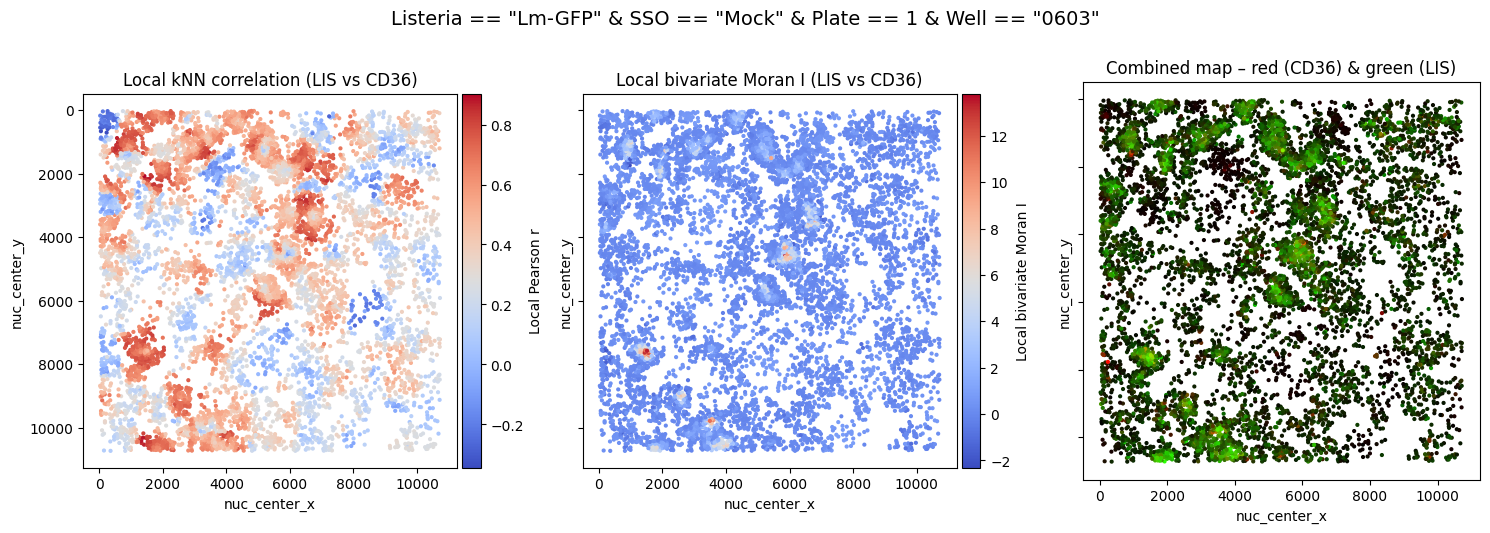

Moran's I (Listeria): 0.6485665726027917 p= 0.001
Moran's I (Cd36): 0.500550376118997 p= 0.001
Bivariate Moran's I: 0.4543527877369532 p= 0.001


In [43]:
test=spatial_correlation_background_Bivariate(combined_df,query_cond,plotsignal=False,plotmoran=False)

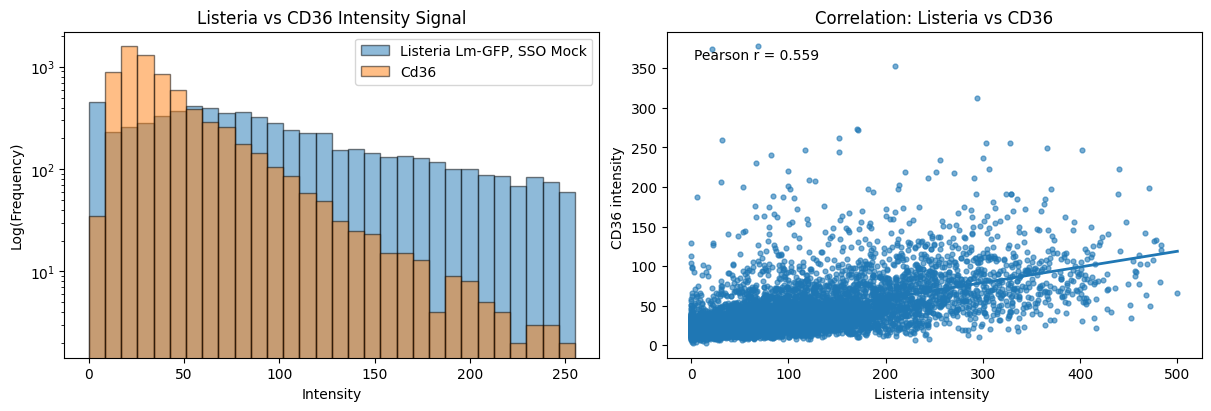

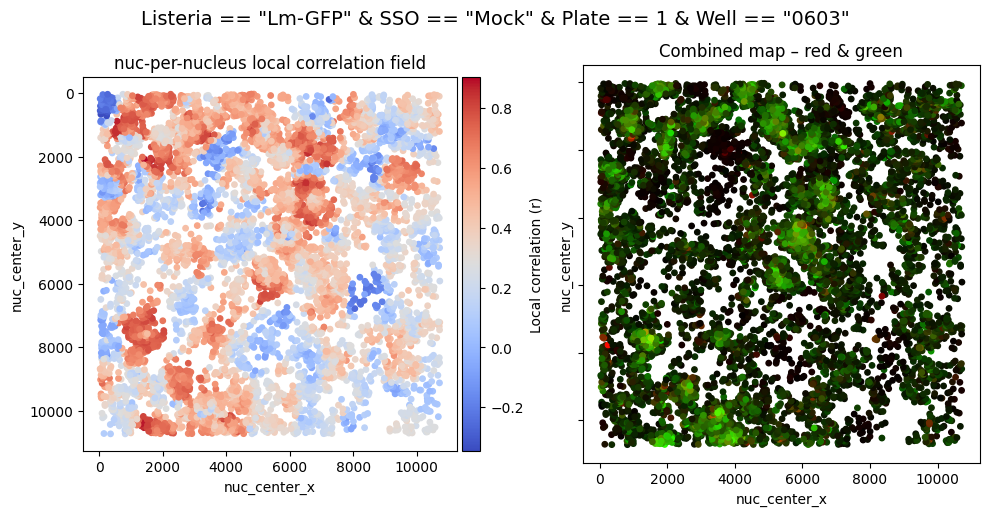

Moran's I (Listeria): 0.6485665726027917 p= 0.001
Moran's I (Cd36): 0.500550376118997 p= 0.001
Bivariate Moran's I: 0.4543527877369532 p= 0.001


In [44]:
spatial_correlation(combined_df,query_cond,plotsignal=True,plotmoran=False)